# Mutual Fund Performance Analytics

## Objective
Perform mutual fund performance analysis including:
- Daily Returns
- CAGR Analysis
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison


In [ ]:
import pandas as pd

nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav_df.head()

In [2]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(
    ['amfi_code', 'date']
)

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
          .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


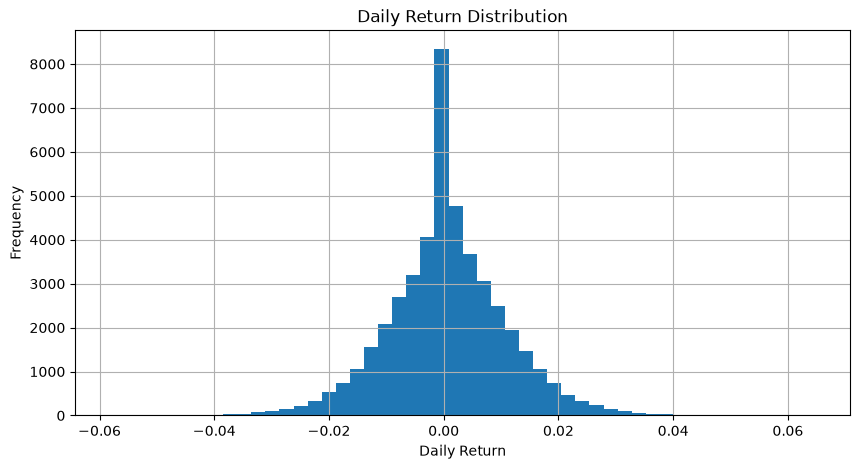

In [9]:
plt.figure(figsize=(10,5))

nav_df['daily_return'].dropna().hist(
    bins=50
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [10]:
# ==================================
# CAGR Calculation
# ==================================

In [11]:
perf_df = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

print(perf_df.columns)

perf_df.head()

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [13]:
cagr_df = perf_df[
    [
        'scheme_name',
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct'
    ]
]

cagr_df.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [14]:
cagr_df = cagr_df.rename(
    columns={
        'return_1yr_pct':'cagr_1yr',
        'return_3yr_pct':'cagr_3yr',
        'return_5yr_pct':'cagr_5yr'
    }
)

cagr_df.head()

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [15]:
sharpe_df = perf_df[
    [
        'scheme_name',
        'sharpe_ratio'
    ]
].copy()

sharpe_df['sharpe_rank'] = (
    sharpe_df['sharpe_ratio']
    .rank(ascending=False)
)

sharpe_df = sharpe_df.sort_values(
    'sharpe_rank'
)

sharpe_df.head(10)

,scheme_name,sharpe_ratio,sharpe_rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.5
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.5
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,9.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,10.0


In [16]:
sortino_df = perf_df[
    [
        'scheme_name',
        'sortino_ratio'
    ]
].copy()

sortino_df['sortino_rank'] = (
    sortino_df['sortino_ratio']
    .rank(ascending=False)
)

sortino_df = sortino_df.sort_values(
    'sortino_rank'
)

sortino_df.head(10)

,scheme_name,sortino_ratio,sortino_rank
14,ICICI Pru Liquid Fund - Regular - Growth,10.37,1.0
23,Kotak Liquid Fund - Regular - Growth,9.70,2.0
30,ABSL Liquid Fund - Regular - Growth,8.76,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,2.79,4.0
19,Nippon India Gilt Securities Fund - Regular - ...,2.38,5.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70,7.0
15,Nippon India Large Cap Fund - Regular - Growth,1.68,8.0
3,SBI Small Cap Fund - Direct Plan - Growth,1.67,9.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66,10.0


In [17]:
alpha_beta = perf_df[
    [
        'scheme_name',
        'alpha',
        'beta'
    ]
]

alpha_beta.to_csv(
    'alpha_beta.csv',
    index=False
)

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [18]:
scorecard = perf_df.copy()

scorecard['return_rank'] = scorecard[
    'return_3yr_pct'
].rank(ascending=False)

scorecard['sharpe_rank'] = scorecard[
    'sharpe_ratio'
].rank(ascending=False)

scorecard['alpha_rank'] = scorecard[
    'alpha'
].rank(ascending=False)

scorecard['expense_rank'] = scorecard[
    'expense_ratio_pct'
].rank(ascending=True)

scorecard['dd_rank'] = scorecard[
    'max_drawdown_pct'
].rank(ascending=False)

In [19]:
scorecard['fund_score'] = (
    0.30 * scorecard['return_rank']
    + 0.25 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.15 * scorecard['expense_rank']
    + 0.10 * scorecard['dd_rank']
)

In [20]:
scorecard['fund_score'] = (
    100 *
    (
        scorecard['fund_score'].max()
        - scorecard['fund_score']
    )
    /
    (
        scorecard['fund_score'].max()
        - scorecard['fund_score'].min()
    )
)

In [21]:
scorecard['final_rank'] = (
    scorecard['fund_score']
    .rank(
        ascending=False
    )
)

In [22]:
fund_scorecard = scorecard[
    [
        'scheme_name',
        'fund_score',
        'final_rank'
    ]
].sort_values(
    'final_rank'
)

fund_scorecard.to_csv(
    'fund_scorecard.csv',
    index=False
)

fund_scorecard.head(10)

,scheme_name,fund_score,final_rank
22,Kotak Flexicap Fund - Regular - Growth,100.000000,1.0
2,SBI Small Cap Fund - Regular Plan - Growth,97.761194,2.0
14,ICICI Pru Liquid Fund - Regular - Growth,97.512438,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,97.014925,4.0
21,Kotak Emerging Equity Fund - Regular - Growth,93.034826,5.0
3,SBI Small Cap Fund - Direct Plan - Growth,92.537313,6.0
34,Mirae Asset Large Cap Fund - Regular - Growth,89.925373,7.0
29,ABSL Small Cap Fund - Regular - Growth,86.567164,8.0
23,Kotak Liquid Fund - Regular - Growth,84.825871,9.0
33,UTI Flexi Cap Fund - Regular - Growth,82.213930,10.0


In [23]:
benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

benchmark_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/10_benchmark_indices_clean.csv'

In [24]:
import os

print(os.listdir("../data/processed"))

['01_fund_master_clean.csv', '02_nav_history_clean.csv', '03_aum_by_fund_house_clean.csv', '04_monthly_sip_inflows_clean.csv', '05_category_inflows_clean.csv', '06_industry_folio_count_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv', '09_portfolio_holdings_clean.csv', '10_benching_indices_clean.csv', 'bluestock_mf_dashboard.pbix', 'investor_transactions_clean.csv', 'nav_history_clean.csv', 'scheme_performance_clean.csv']


In [25]:
benchmark_df = pd.read_csv(
    "../data/processed/10_benching_indices_clean.csv"
)

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [26]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [27]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [28]:
top5 = fund_scorecard.head(5)

top5

,scheme_name,fund_score,final_rank
22,Kotak Flexicap Fund - Regular - Growth,100.000000,1.0
2,SBI Small Cap Fund - Regular Plan - Growth,97.761194,2.0
14,ICICI Pru Liquid Fund - Regular - Growth,97.512438,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,97.014925,4.0
21,Kotak Emerging Equity Fund - Regular - Growth,93.034826,5.0


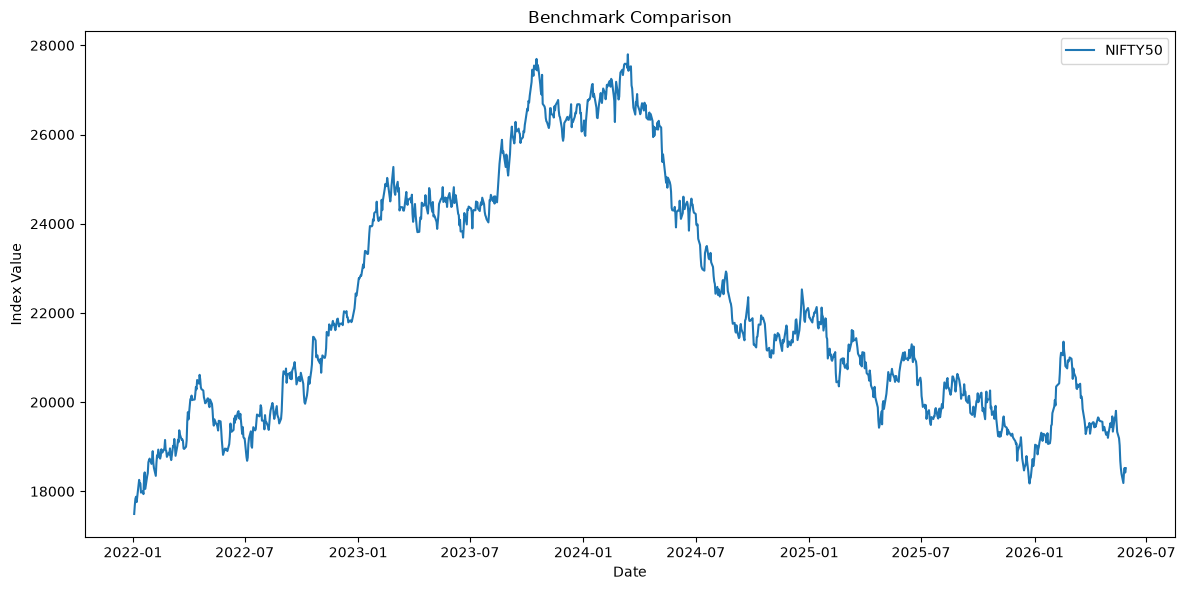

In [29]:
import matplotlib.pyplot as plt

benchmark_df['date'] = pd.to_datetime(
    benchmark_df['date']
)

nifty50 = benchmark_df[
    benchmark_df['index_name'] == 'NIFTY50'
]

plt.figure(figsize=(12,6))

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50'
)

plt.title(
    'Benchmark Comparison'
)

plt.xlabel('Date')
plt.ylabel('Index Value')

plt.legend()

plt.tight_layout()

plt.savefig(
    'benchmark_comparison.png'
)

plt.show()

In [30]:
fund_scorecard.to_csv(
    'fund_scorecard.csv',
    index=False
)

alpha_beta.to_csv(
    'alpha_beta.csv',
    index=False
)

## Conclusion

Generated Deliverables:
- fund_scorecard.csv
- alpha_beta.csv
- benchmark_comparison.png

Top funds were identified using a composite scoring methodology combining returns, risk-adjusted performance, expenses, and drawdown metrics.